<a href="https://colab.research.google.com/github/sabithakrishnan/Survival-Models/blob/main/cox_proportional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install lifelines

/usr/local/lib/python3.13/dist-packages/lifelines/utils/__init__.py:1120: ConvergenceWarning: Column is_treatment have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['event_observed'].astype(bool)
>>> print(df.loc[events, 'is_treatment'].var())
>>> print(df.loc[~events, 'is_treatment'].var())

A very low variance means that the column is_treatment completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/usr/local/lib/python3.13/dist-packages/lifelines/fitters/coxph_fitter.py:1607: ConvergenceWarning: Newton-Raphson convergence completed successfully but norm(delta) is still high, 0.513. This may imply non-unique solutions to the maximum likelihood. Perhaps there is collinearit

<lifelines.CoxPHFitter: fitted with 20 total observations, 10 right-censored observations>
             duration col = 'duration'
                event col = 'event_observed'
      baseline estimation = breslow
   number of observations = 20
number of events observed = 10
   partial log-likelihood = -15.10
         time fit was run = 2026-09-14 13:18:41 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
is_treatment -19.16      0.00   2916.20        -5734.80         5696.48                0.00                 inf

              cmp to     z    p  -log2(p)
covariate                                
is_treatment    0.00 -0.01 0.99      0.01
---
Concordance = 0.84
Partial AIC = 32.21
log-likelihood ratio test = 22.92 on 1 df
-log2(p) of ll-ratio test = 19.17

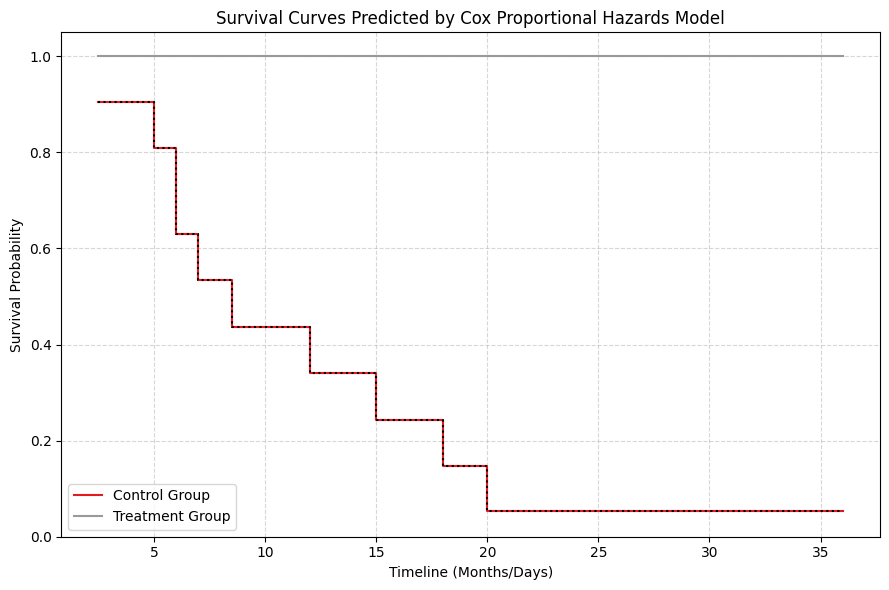

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from lifelines import CoxPHFitter

# 1. Prepare the same sample data
data = {
    'duration': [5, 6, 6, 2.5, 7, 8.5, 12, 15, 18, 20, 12, 14, 19, 22, 24, 25, 28, 30, 32, 36],
    'event_observed': [1]*10 + [0]*10, # Added a list of boolean values for observed events
    # Convert 'group' string column into a numeric dummy indicator for the Cox model (1 = Treatment, 0 = Control)
    'is_treatment': [0]*10 + [1]*10
}
df = pd.DataFrame(data)

# 2. Initialize and fit the Cox Proportional Hazards model
cph = CoxPHFitter()
cph.fit(df, duration_col='duration', event_col='event_observed')

# Print out Hazard Ratios, p-values, and statistical coefficients
cph.print_summary()

# 3. Plot the predicted survival curves using the Cox model
fig, ax = plt.subplots(figsize=(9, 6))

# Plot partial effects allows us to see how changing 'is_treatment' from 0 to 1 alters survival
cph.plot_partial_effects_on_outcome(
    covariates='is_treatment',
    values=[0, 1],
    cmap='Set1',
    ax=ax
)

# 4. Finalize plot formatting to match your previous look
ax.set_title('Survival Curves Predicted by Cox Proportional Hazards Model')
ax.set_xlabel('Timeline (Months/Days)')
ax.set_ylabel('Survival Probability')
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle='--', alpha=0.5)

# Update legend to clearly state groups instead of just numeric values
ax.legend(['Control Group', 'Treatment Group'])

plt.tight_layout()
plt.show()